In [1]:
%load_ext autoreload
%autoreload 2


import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tensorflow_probability.substrates import jax as tfp

from qdots_qll.distributions import (
    Distribution,
)
from qdots_qll.exp_design import RandExpDesignGAME
from qdots_qll.models.single_dot_weak_coupling_GAME import (
    Data,
    ExperimentSingleDotWeakCouplingGAME,
    SingleDotWeakCouplingGAME,
)
from qdots_qll.resamplers import LiuWestResampler, MetropolisSampler
from qdots_qll.smc import SMCUpdater


In [2]:
seed = 0
key = jax.random.key(seed=seed)
key, subkey = jax.random.split(key)


In [3]:
model = SingleDotWeakCouplingGAME()

boundaries = jnp.array(
    [
        [0.1, 0.5],
        [0.1, 0.5],
        [0.01, 0.2],
        [-0.5, -0.01],
    ]
)


loc = boundaries.mean(axis=1)
scale = boundaries.std(axis=1)


truncated_norm = tfp.distributions.TruncatedNormal(
    loc=loc, scale=scale / 1.5, low=boundaries[:, 0], high=boundaries[:, 1]
)

no_particles = 500
init_particles_locations = truncated_norm.sample(
    seed=subkey, sample_shape=(no_particles,)
)
weights = jnp.ones(no_particles) / no_particles

dist = Distribution(particles_locations=init_particles_locations, weights=weights)


exp_design = RandExpDesignGAME()
resampler = MetropolisSampler(boundaries=boundaries, model=model)
# resampler = LiuWestResampler(boundaries=boundaries)


smc = SMCUpdater(model=model, exp_design=exp_design, resampler=resampler)


key, subkey = jax.random.split(key)

fake_first_data = Data(ExperimentSingleDotWeakCouplingGAME(-9999, 9999, 99999), 9999)
data = fake_first_data

max_iterations = 10
iteration = 0


2024-08-26 18:31:39.521665: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-08-26 18:31:39.541053: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-08-26 18:31:39.546282: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-08-26 18:31:40.421448: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [5]:
with jax.profiler.trace("tmp/tensorboard"):
    # Run the operations to be profiled
    key, dist, data = smc.step(iteration=iteration, key=key, dist=dist, data=data)

In [4]:
# df = pd.DataFrame(np.array(dist.particles_locations))
# sns.pairplot(data=df)

In [110]:
# from qdots_qll.smc import do_not_resample

In [7]:
from qdots_qll.smc import SMCUpdater

exp_design = RandExpDesignGAME()
resampler = MetropolisSampler(boundaries=boundaries, model=model)
# resampler = LiuWestResampler(boundaries=boundaries)


smc = SMCUpdater(model=model, exp_design=exp_design, resampler=resampler)


rmse_list = []
no_particles = int(500)
init_particles_locations = truncated_norm.sample(
    seed=subkey, sample_shape=(no_particles,)
)
weights = jnp.ones(no_particles) / no_particles

dist = Distribution(particles_locations=init_particles_locations, weights=weights)


key, subkey = jax.random.split(key)

fake_first_data = Data(ExperimentSingleDotWeakCouplingGAME(-9999, 9999, 99999), 9999)

data = fake_first_data

max_iterations = 10
iteration = 0
for _ in range(max_iterations):
    key, dist, data = smc.step(iteration=iteration, key=key, dist=dist, data=data)
    if iteration == 0:
        data = data[1:]

    rmse = jnp.sqrt((model.true_parameters - dist.ev()) ** 2)
    rmse_list.append(rmse)

    if iteration % 10 == 0:
        print(dist.ev())
        print(jnp.diag(dist.cov()))

        print(f"RMSE: {rmse}")
        print("\n")
    iteration = iteration + 1


[ 0.29812717  0.30307204  0.10429435 -0.2569945 ]
[0.00979454 0.00981373 0.002129   0.01443633]
RMSE: [0.01608974 0.05525804 0.05044286 0.07670033]




RuntimeError: Profile has already been started. Only one profile may be run at a time.

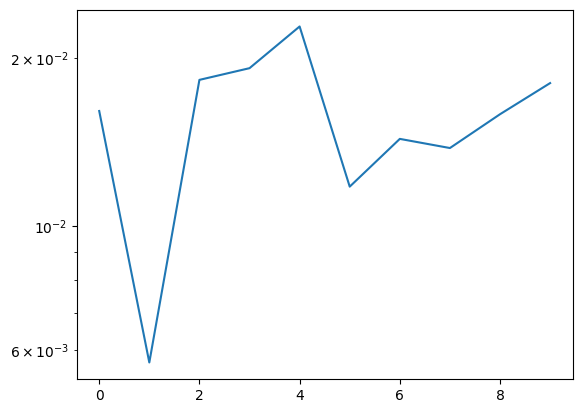

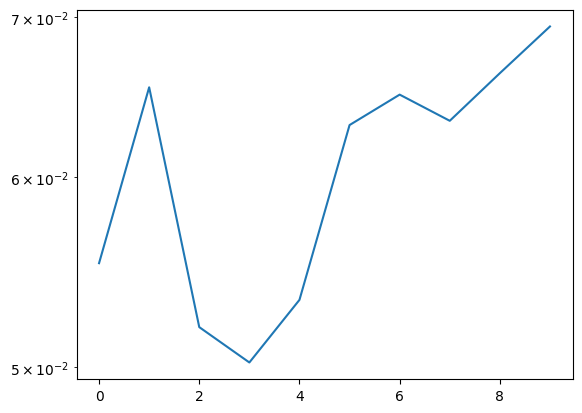

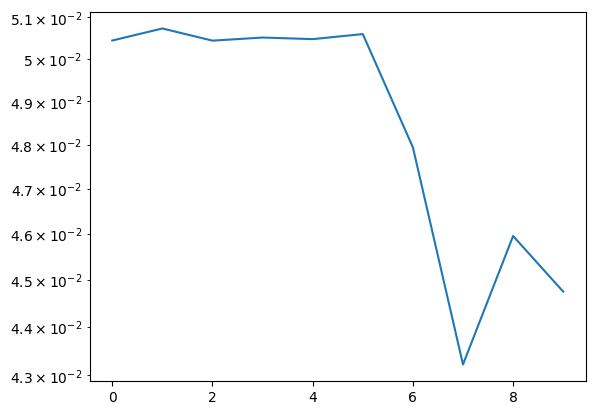

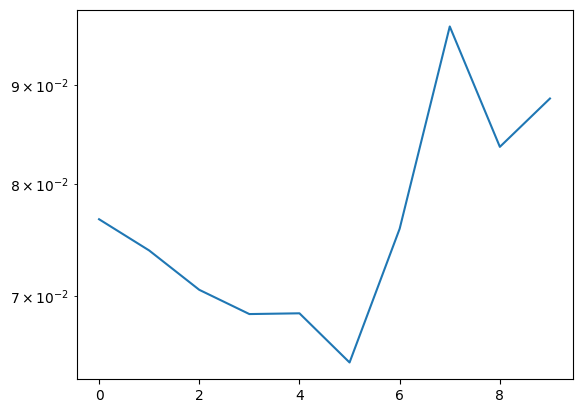

In [8]:
for i in range(4):
    plt.plot(np.array(rmse_list)[:, i])
    plt.yscale("log")
    plt.show()

In [9]:
dist.cov()

Array([[9.49276984e-03, 1.36562437e-03, 1.79482624e-04, 7.86334276e-05],
       [1.36562437e-03, 9.59923118e-03, 1.11125410e-04, 2.95095146e-04],
       [1.79482624e-04, 1.11121684e-04, 2.05902196e-03, 2.86102295e-04],
       [7.86334276e-05, 2.95095146e-04, 2.86102295e-04, 1.27027296e-02]],      dtype=float32)

In [10]:
dist.ev()


Array([ 0.29616302,  0.2889712 ,  0.09860546, -0.24516374], dtype=float32)

In [60]:
import arviz as az

az.plot_dist()

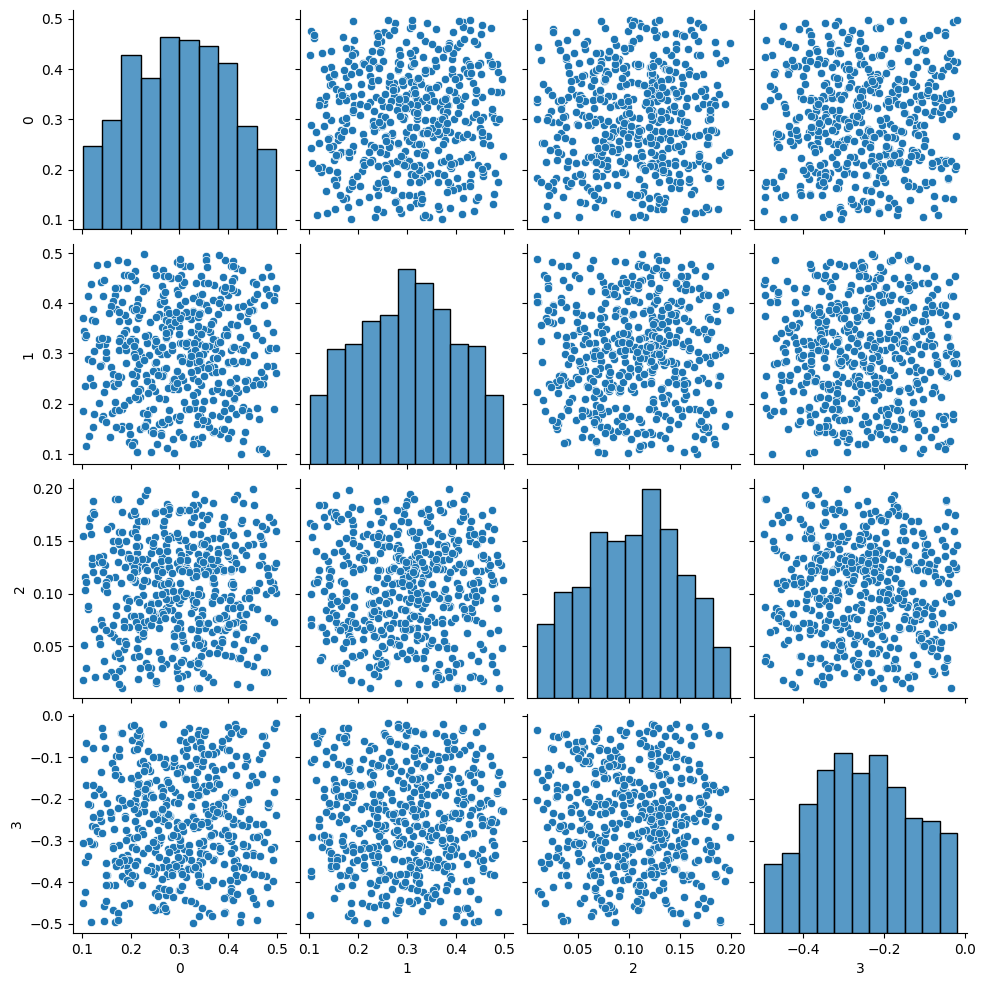

In [11]:
df = pd.DataFrame(np.array(dist.particles_locations))
sns.pairplot(data=df)

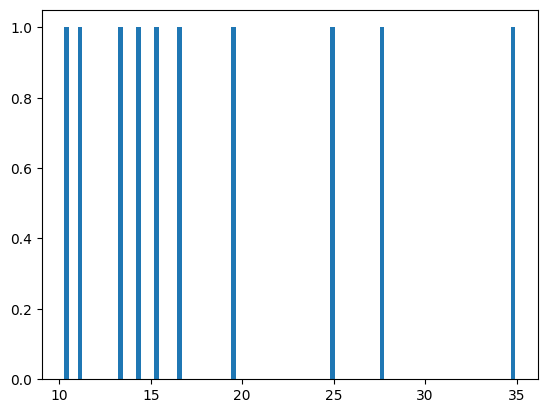

In [12]:
plt.hist(np.array(data.experiment.time), bins=100)
plt.show()

In [10]:
# LIU WEST


from qdots_qll.smc import SMCUpdater

exp_design = RandExpDesignGAME()
# resampler = MetropolisSampler(boundaries=boundaries, model=model)
resampler = LiuWestResampler(boundaries=boundaries)


smc = SMCUpdater(model=model, exp_design=exp_design, resampler=resampler)


rmse_list = []
no_particles = 500
init_particles_locations = truncated_norm.sample(
    seed=subkey, sample_shape=(no_particles,)
)
weights = jnp.ones(no_particles) / no_particles

dist = Distribution(particles_locations=init_particles_locations, weights=weights)


key, subkey = jax.random.split(key)
fake_first_exp = ExperimentSingleDotWeakCouplingGAME(-9999, 9999, 99999)
fake_first_output = 9999
fake_first_data = Data(fake_first_exp, fake_first_output)

data = fake_first_data

max_iterations = 100
iteration = 0
for _ in range(max_iterations):
    key, dist, data = smc.step(iteration=iteration, key=key, dist=dist, data=data)
    if iteration == 0:
        data = data[1:]

    rmse = jnp.sqrt((model.true_parameters - dist.ev()) ** 2)
    rmse_list.append(rmse)

    if iteration % 10 == 0:
        print(dist.ev())
        print(jnp.diag(dist.cov()))

        print(f"RMSE: {rmse}")
        print("\n")
    iteration = iteration + 1


[ 0.2822172   0.2984213   0.10320964 -0.25914913]
[0.01021602 0.00938345 0.00224625 0.01413547]
RMSE: [0.03199971 0.05990878 0.04935815 0.07454568]


[ 0.29816246  0.31492406  0.10690843 -0.28262955]
[0.00987353 0.00900532 0.00227776 0.01335681]
RMSE: [0.01605445 0.04340601 0.05305694 0.05106527]


[ 0.29595602  0.3354926   0.10502896 -0.25727886]
[0.0091109  0.00727112 0.00230991 0.01410601]
RMSE: [0.0182609  0.02283746 0.05117747 0.07641596]


[ 0.29192635  0.3515803   0.12264812 -0.33315715]
[0.00936046 0.00675438 0.00209212 0.00978239]
RMSE: [0.02229056 0.00674978 0.06879663 0.00053766]


[ 0.2632948   0.35476905  0.11491431 -0.31385672]
[0.00872224 0.00700627 0.00210758 0.00899803]
RMSE: [0.05092213 0.00356102 0.06106282 0.01983809]


[ 0.25883412  0.37778157  0.11261185 -0.29559648]
[0.00792673 0.00538442 0.00209532 0.00927289]
RMSE: [0.05538279 0.0194515  0.05876036 0.03809834]


[ 0.26611966  0.36321482  0.10864079 -0.28692192]
[0.00789578 0.00594744 0.0023416  0.00923098]
RMSE

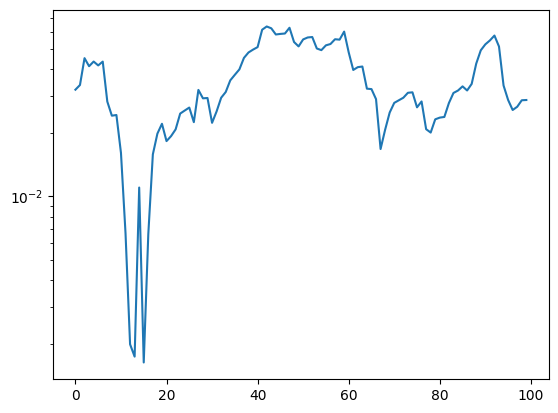

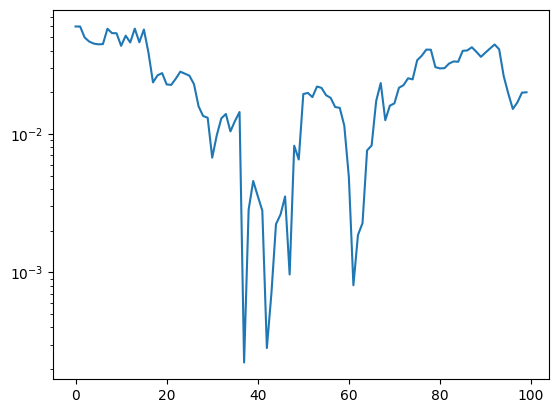

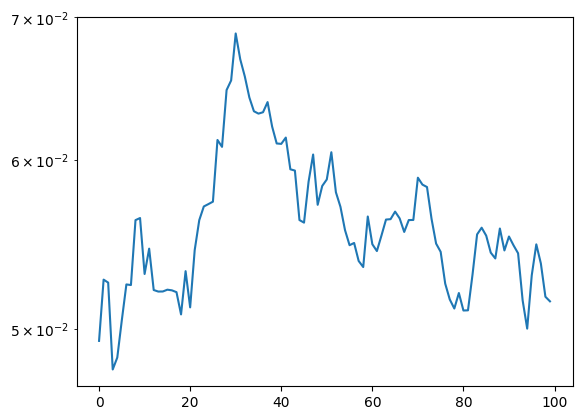

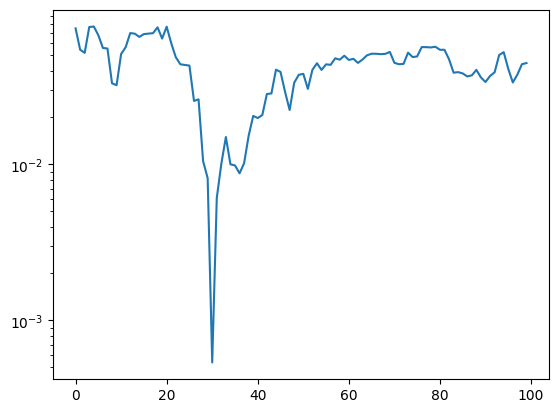

In [11]:
for i in range(4):
    plt.plot(np.array(rmse_list)[:, i])
    plt.yscale("log")
    plt.show()